# 

# Network Clustering
## Description
This notebook explores the reduced network model included with Pypsa-Canada-National. The model contains 23 buses along with the aggregate interconnections between them.

### Loading Data

In [6]:
import geopandas as gpd
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg
import os
import matplotlib.pyplot as plt

from helper_functions import mapLines

In [7]:
path = os.getcwd()
data_path = os.path.join(path, 'data', 'processed_data')
all_lines = gpd.read_feather(os.path.join(data_path, 'line_data.feather')).to_crs('EPSG: 4326')
zone_data = gpd.read_feather(os.path.join(data_path, 'zone_data.feather')).to_crs('EPSG: 4326')
node_data = gpd.read_feather(os.path.join(data_path, 'node_data.feather')).to_crs('EPSG: 4326')

## Clustering
Leiden clustering was used on the CODERS nodes/lines as a first step, to identify areas that are highly connected
1. The transmission lines are aggregated within the census areas, making the assumption that transmission within the census area is infinite. This was done as an initial filtering step to reduce the complexity of the problem.

In [8]:
# Remove lines that start and end in the same zone
all_inter_census_lines = all_lines[(all_lines.CDUID_1 != all_lines.CDUID_2)]

2. The data was then converted to a graph, where the nodes are the census areas and the edges are the transmission lines between them (where the edge weightings used were the voltages from CODERS)

In [9]:
def create_graph(nodes, edges, province):
    ### CREATING GRAPH
    G = nx.Graph()
    for CDUID, row in nodes.iterrows():
        G.add_node(int(CDUID))
    for _, row in edges.iterrows():
        G.add_edge(int(row['CDUID_1']), int(row['CDUID_2']), capacity=row['voltage'])
    # Converting to igraph
    G_ig = ig.Graph.Adjacency((nx.to_numpy_array(G) > 0).tolist())
    print(f'{province} map: {G}')
    return G_ig

3. A Leiden clustering algorithm was then applied to the graph. It was chosen as it is a better community detection algorithm than Louvain (which was also tried)

In [10]:
def leiden_cluster(graph, province):
    ### LEIDEN CLUSTERS
    leiden_clusters = leidenalg.find_partition(graph, leidenalg.ModularityVertexPartition)
    leiden_comm_map = {}
    for i, cluster in enumerate(leiden_clusters):
        for node in cluster:
            leiden_comm_map[int(node)] = i
    print(f'{province} Leiden clusters: {i + 1}')
    return pd.Series(leiden_comm_map)

The above steps are run for all of the provinces individually to ensure clusters remain within provincial boundaries. For this reason, lines between the provinces are exlcuded from the graph. Only regions connected to the rest of the grid by one or more transmission lines are included in the graph.

In [15]:
# storing all provincial results
all_clusters = pd.DataFrame()
for province in zone_data.province.unique():
    # All lines in province, not just interzonal
    # Remove inter-provincial lines
    edges = all_inter_census_lines[(all_inter_census_lines.province_1 == province) & (all_inter_census_lines.province_1 == all_inter_census_lines.province_2)]
    # Only zones/nodes within province
    zones = zone_data[(zone_data.province == province) & (zone_data.Connected)]

    if zones.empty:
        print(f'No connected zones in {province}')
        continue
    elif edges.empty:
        print(f'No connected lines in {province}')
        continue
    
    # Cluster provincial zones
    graph = create_graph(zones, edges, province)
    clusters = leiden_cluster(graph, province).astype(str)
    zones = zones.reset_index()
    zones['cluster'] = province + '_' + clusters
    zones = zones.set_index('CDUID', drop=True)
    all_clusters = pd.concat([all_clusters, zones[['CSDNAME', 'province', 'geometry', 'cluster']]])

# Saving to a csv
print(f'Total number of clusters is: {len(all_clusters.cluster.unique())}')
all_clusters['manual_cluster'] = all_clusters['cluster']
all_clusters.drop('geometry',axis=1).to_csv(os.path.join(path, 'results', 'cluster_data.csv'))

NL map: Graph with 10 nodes and 14 edges
NL Leiden clusters: 3
PE map: Graph with 3 nodes and 2 edges
PE Leiden clusters: 1
NS map: Graph with 18 nodes and 30 edges
NS Leiden clusters: 3
NB map: Graph with 15 nodes and 27 edges
NB Leiden clusters: 3
QC map: Graph with 95 nodes and 177 edges
QC Leiden clusters: 8
ON map: Graph with 49 nodes and 90 edges
ON Leiden clusters: 5
MB map: Graph with 23 nodes and 45 edges
MB Leiden clusters: 4
SK map: Graph with 18 nodes and 32 edges
SK Leiden clusters: 4
AB map: Graph with 19 nodes and 38 edges
AB Leiden clusters: 4
BC map: Graph with 27 nodes and 40 edges
BC Leiden clusters: 5
No connected zones in YT
No connected zones in NT
No connected zones in NU
Total number of clusters is: 40


### The resulting set of clusters

In [16]:
# This step is very slow
all_clusters = all_clusters.dissolve(by='cluster', aggfunc='first')

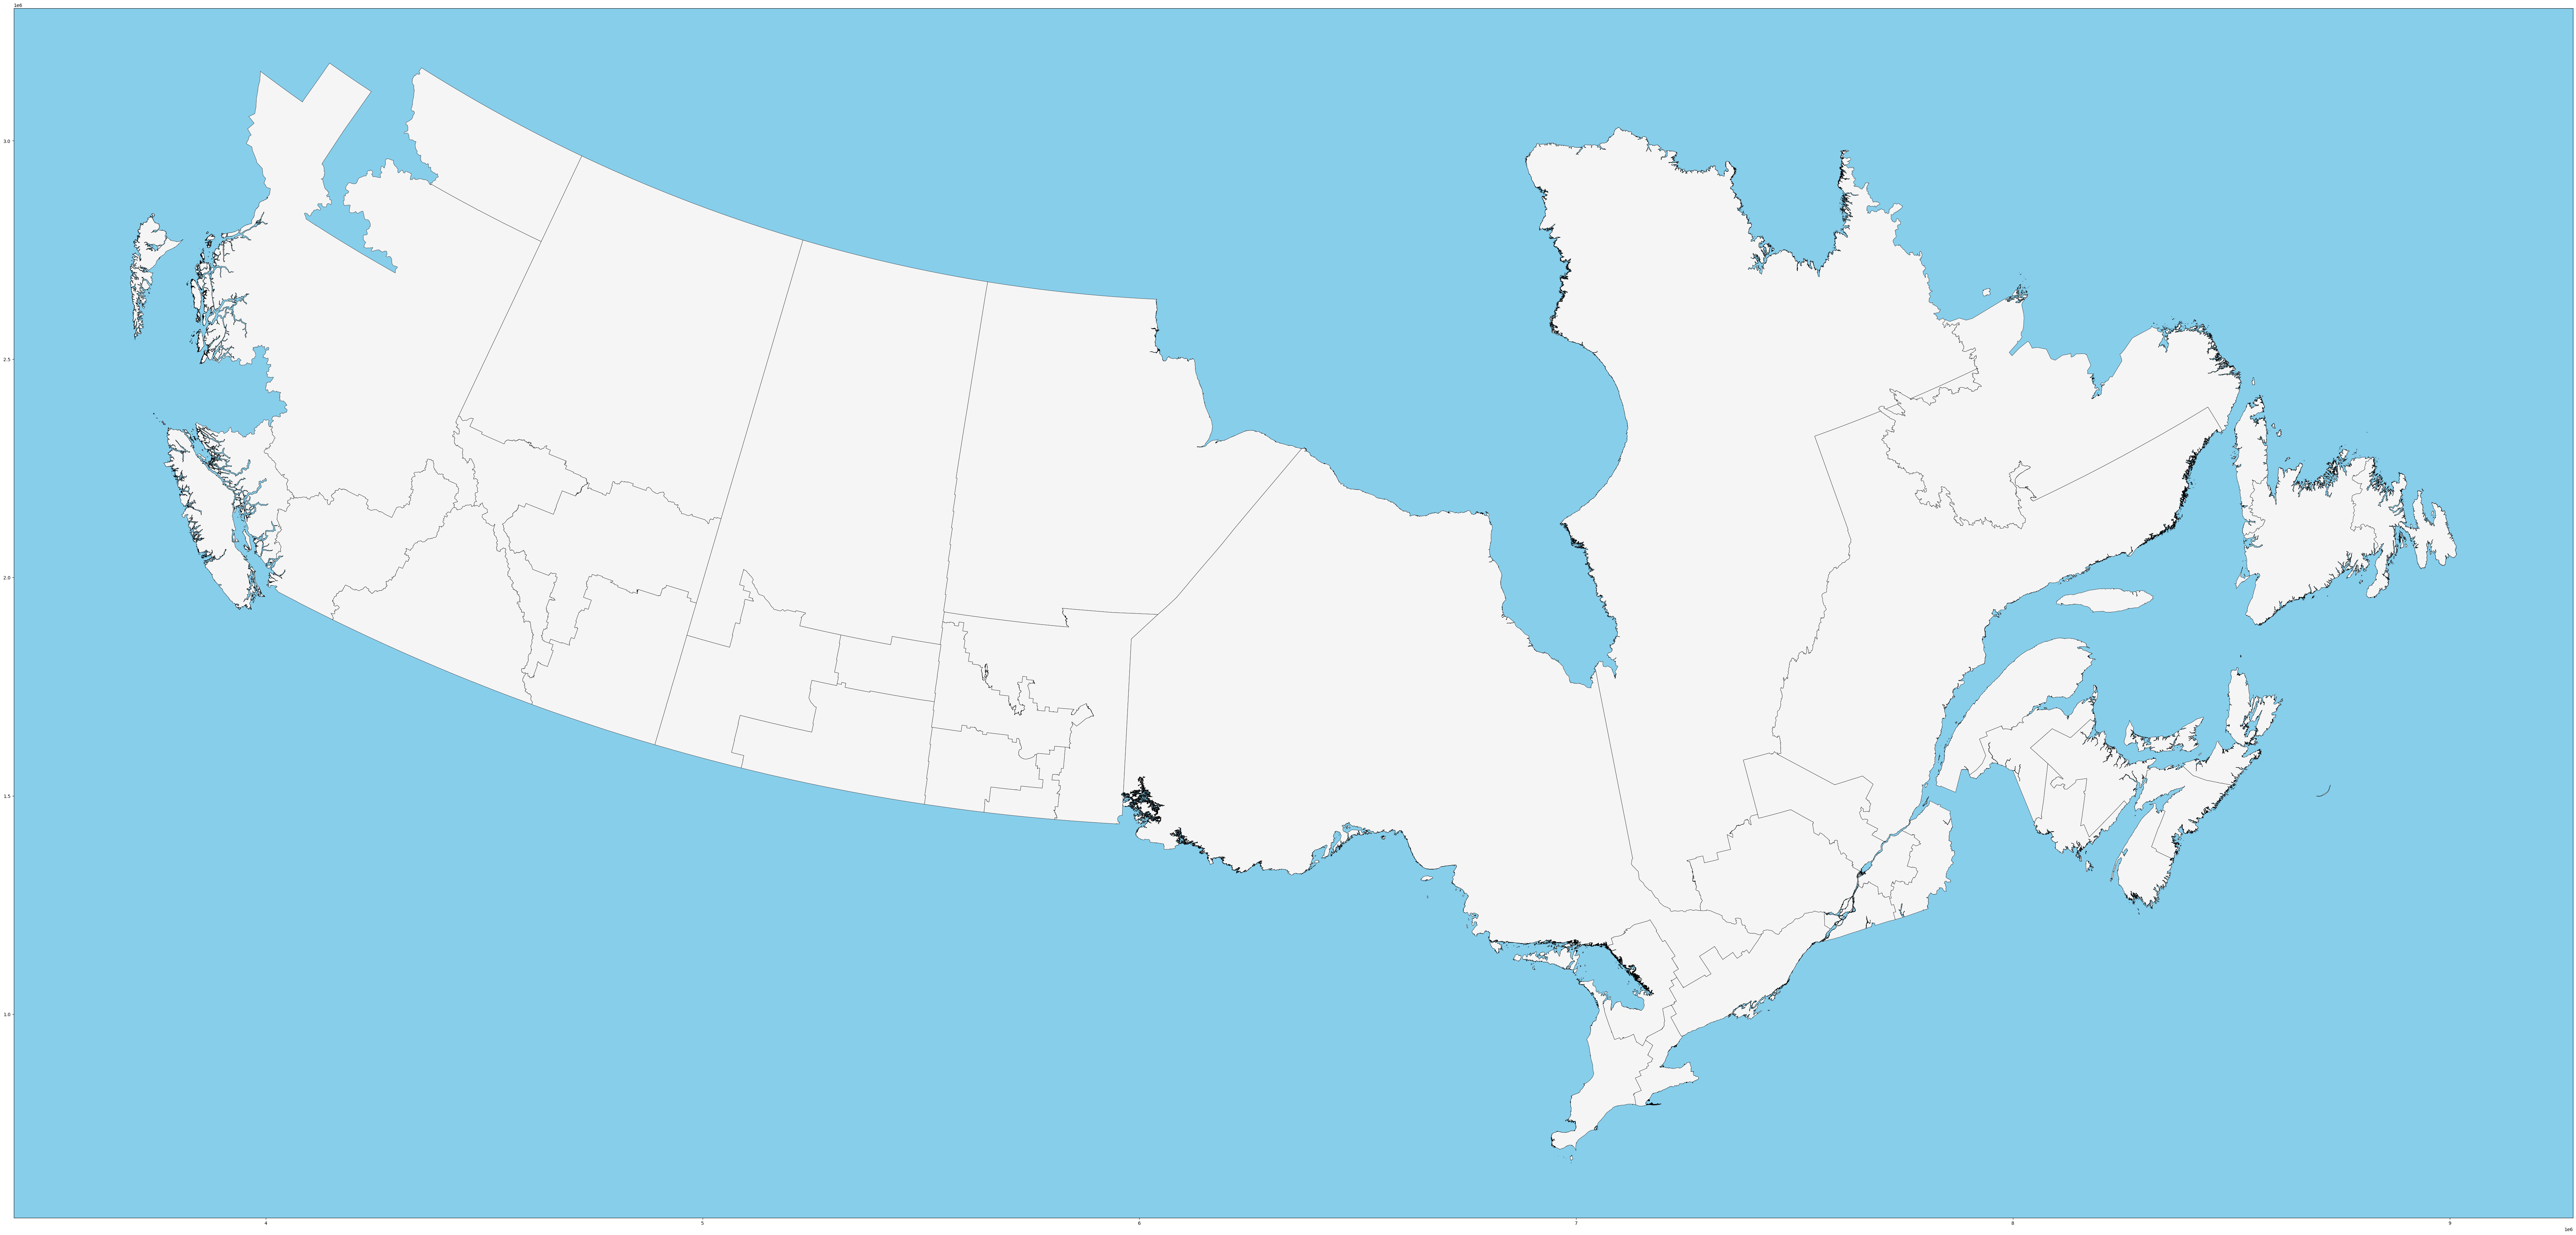

In [17]:
all_clusters = all_clusters.to_crs('EPSG: 3347')
all_clusters['colour'] = 'whitesmoke'
fig, ax = plt.subplots(figsize = (100,100))
ax.set_facecolor('skyblue')
all_clusters.plot(ax=ax, color=all_clusters.colour, edgecolor='black', linewidth=0.5)
os.makedirs(os.path.join(path, 'results', 'visualizations'), exist_ok=True)
plt.savefig(os.path.join(path, 'results', 'visualizations', 'leiden_clusters.png'))

The leiden clustering resulted in too many nodes being retained (30+), some manual aggregation was done. Clusters were merged to reduce total number, based on transmission constraints, load centers, and generation considerations
1. MB and SK were consolidated into a single node each, as the load centers are focused in the south, where transmission corridors are likely to appear
2. NB, BC, NS reduced to 2 nodes each – north/south for BC and east/west for NB and NS
3. Nodes were added in Ontario to represent the transmission-constrained north-west. They were further modified to better align with the IESO transmission planning regions. The nodes roughly represent Northwest, northeast, ESSA + East (eastern Ontario), southwest + bruce + niagara + west (southern ontario), and Toronto 
4. Alberta was split into 3 nodes – south (Calgary), central (Edmonton) and north (oil sands)
5. QC was split into 4 nodes, one for the highly concentrated hydro assets in the north (and high wind potential), one for the large load centers in the south, one for the transmission corridor between labrador and Quebec city, and one for the eastern portion and interconnection with NB
6. Newfoundland and labrador separated
7. The disconnected regions were assigned to the nearest cluster

### The finalized Canada-23 Bus model
To use the pre-defined 23 bus model, set CUSTOM = False. Otherwise, make a copy of 'cluster_data.csv' in the results folder, modify the manual_cluster column, and save the changes in 'cluster_data_manual.csv'.

In [18]:
CUSTOM = False

if CUSTOM:
    # Reading manually created cluster data
    cluster_data = pd.read_csv(os.path.join(path, 'results', 'cluster_data_manual.csv'),index_col=0)
else:
    cluster_data = pd.read_csv(os.path.join(path, 'data', 'cluster_data_default.csv'), index_col=0)
zone_data['cluster'] = cluster_data['manual_cluster']
zone_data = zone_data.dissolve(by='cluster', aggfunc='sum')

#### Saving results

In [19]:
# Saving clustered zone data
zone_data = zone_data.drop(['DGUID', 'CSDNAME', 'CDTYPE', 'PRUID', 'province', 'Connected'], axis=1)
zone_data.to_feather(os.path.join(path, 'results',  'clustered_zone_data.feather'))
zone_data.drop(['geometry'], axis=1).to_csv(os.path.join(path, 'results', 'intermediary_outputs', 'clustered_zone_data.csv'))

# Saving node-cluster mapping
node_lookup = gpd.sjoin(node_data, zone_data[['geometry']], how='left', predicate='within')
node_lookup.to_feather(os.path.join(path, 'results', 'node_data.feather'))
node_lookup['cluster'].to_csv(os.path.join(path, 'results', 'intermediary_outputs', 'node_lookup.csv'))

## Find which clusters the lines fall between
all_lines = all_lines[['node_1', 'node_2', 'line_segment_length_km', 'voltage', 'capacity', 'CDUID_1', 'CDUID_2', 'province_1', 'province_2']]
all_lines = pd.merge(all_lines, node_lookup[['cluster', 'geometry']], how='left', left_on='node_1', right_index=True)
all_lines = pd.merge(all_lines, node_lookup[['cluster', 'geometry']], how='left', left_on='node_2', right_index=True, suffixes=['_1', '_2'])
gpd.GeoDataFrame(mapLines(all_lines)).to_feather(os.path.join(path, 'results', 'line_data.feather'))

c:\Users\ndematos\envs\pypsa_canada_py312\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


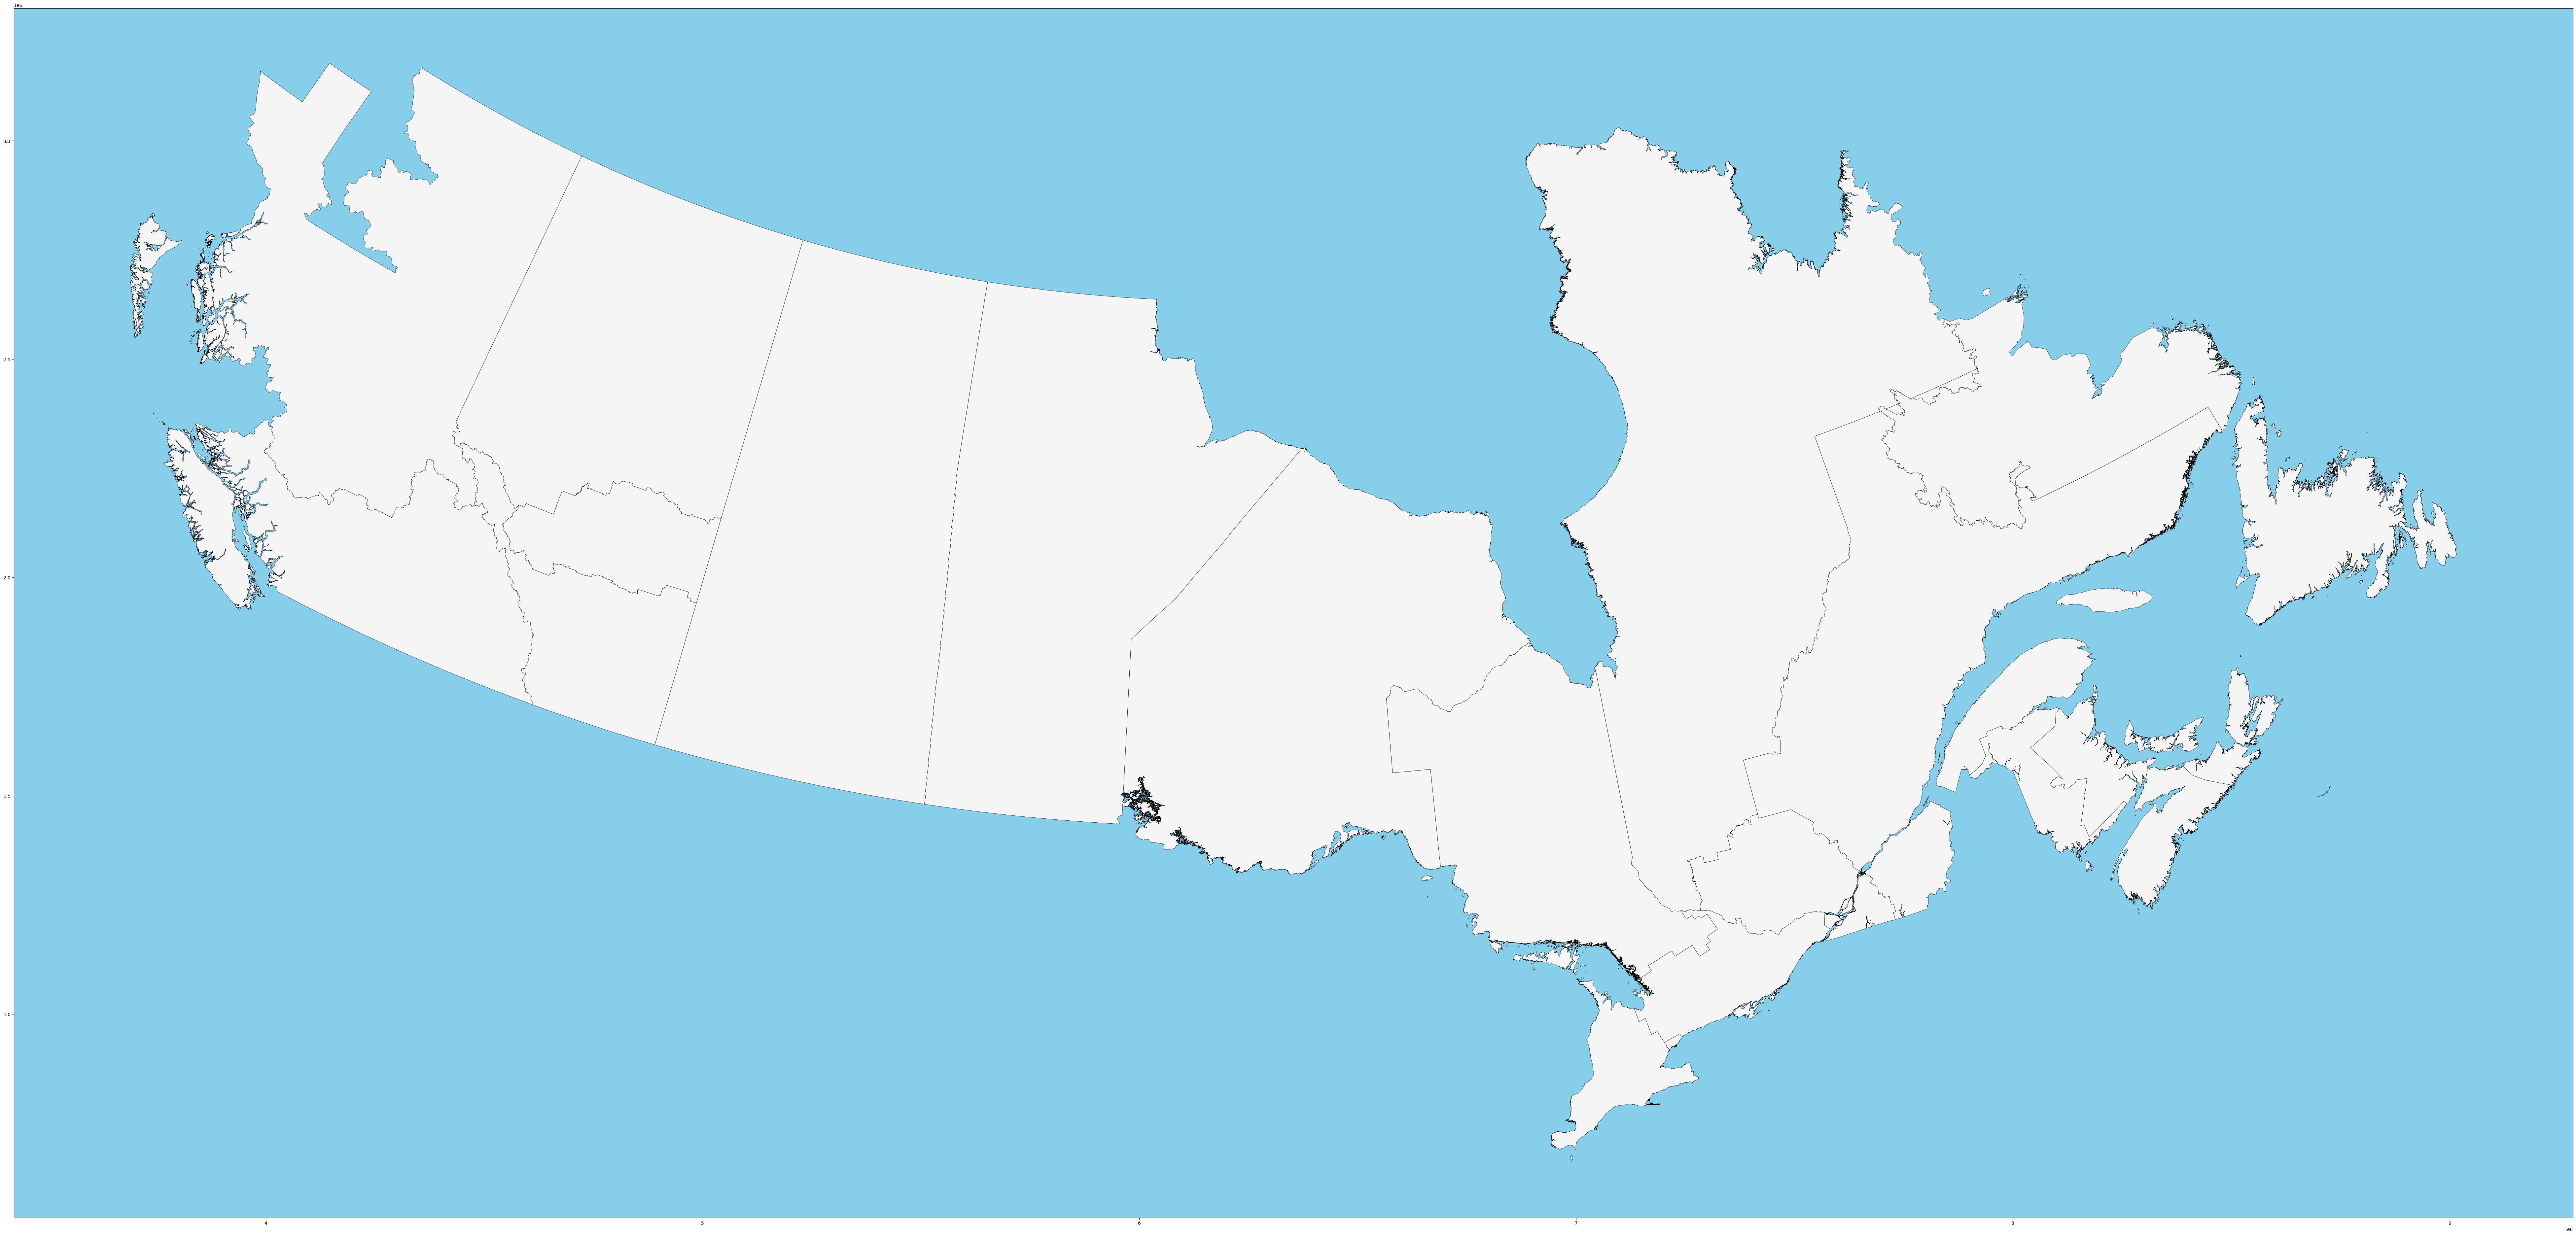

In [20]:
zone_data = zone_data.to_crs('EPSG: 3347')
zone_data['colour'] = 'whitesmoke'
fig, ax = plt.subplots(figsize = (100,100))
ax.set_facecolor('skyblue')
zone_data.plot(ax=ax, color=zone_data.colour, edgecolor='black', linewidth=0.5)
plt.savefig(os.path.join(path, 'results', 'visualizations', 'clusters.png'))